# Predicción de cancelación de citas
## Sistema integral multiplataforma para la gestión de citas, cursos y comercio electronico salón Brenn's

In [1]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Comprensión del negocio

**Contexto y proceso:** Salón Brenn's agenda citas de servicios (manicura, uñas esculturales, etc.) a través de su sistema web. El proceso al que pertenece esta solución es el de **agenda y confirmación de citas**: un cliente reserva un horario, y esa cita puede terminar realizándose o siendo cancelada antes de la fecha.

**Problema de negocio:** una cita cancelada sin aviso deja un hueco en la agenda que ya no se puede llenar a tiempo, y representa un ingreso perdido para el negocio.

**Objetivo analítico:** predecir, **antes de la fecha programada y usando solo información disponible en el momento de agendar**, si una cita tiene riesgo de cancelarse.

**Definición de las clases (variable objetivo `se_cancela`):**
- **Clase 0 — No se cancela:** la cita llegó a su fecha con estado `CONFIRMADA` (no fue cancelada por el cliente ni por el administrador).
- **Clase 1 — Se cancela:** la cita fue cancelada explícitamente en el sistema (`estado = 'CANCELADA'`), ya sea por el cliente o por el administrador.

**Limitación de alcance importante:** el sistema actual no registra una asistencia real distinta de la cancelación (no existe un estado tipo "completada/asistió" que se use en la práctica) — así que este modelo predice específicamente **cancelación explícita registrada en el sistema**, no "no-show" en general. Una cita a la que el cliente simplemente no asistió sin cancelar formalmente queda clasificada como "no se cancela", porque es la única información que el sistema actual captura.

**Usuario que recibe el resultado:** el **personal administrativo** (panel de citas), quien vería una señal de riesgo por cita próxima para decidir si llamar para confirmar, enviar un recordatorio extra, o liberar el horario a tiempo para otro cliente.

**Decisión que apoya:** priorizar a qué citas próximas darles seguimiento proactivo (llamada, recordatorio) antes de que se conviertan en una cancelación de último momento.

**Beneficio esperado:** reducir huecos de agenda no aprovechados y el ingreso perdido asociado.

## 2. Comprensión de los datos

### 2.1 Esquema relevante y proceso de extracción

```
agenda.tblcitas → catalogos.tblservicios → catalogos.tblcategorias_servicios → agenda.tblcitas → seguridad.tblusuarios 
```


**Consulta SQL utilizada para extraer el dataset** (ejecutada por `04_ETL/etl_extraer_citas.py`):

```sql
SELECT c.id, c.usuario_id, c.fecha, c.created_at, c.hora, c.metodo_pago, c.estado,
       s.id, s.nombre, cs.nombre, s.precio, s.duracion, u.fecha_registro
FROM agenda.tblcitas c
JOIN catalogos.tblservicios s ON s.id = c.servicio_id
LEFT JOIN catalogos.tblcategorias_servicios cs ON cs.id = s.categoria_id
LEFT JOIN seguridad.tblusuarios u ON u.id = c.usuario_id
WHERE c.fecha < NOW()
```

**Filtro clave:** solo citas cuya `fecha` ya pasó — una cita futura aún `PENDIENTE`/`CONFIRMADA` todavía no tiene un resultado decidido, incluirla sería mezclar casos resueltos con casos abiertos.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import os
CANDIDATAS = ['../05_Datasets', './05_Datasets', '/content/05_Datasets']
RUTA_DATASETS = next(
    (r for r in CANDIDATAS if os.path.exists(f'{r}/dataset_citas.csv')), None)
assert RUTA_DATASETS, (
    'No se encontró 05_Datasets/dataset_citas.csv. '
    'Coloque la carpeta 05_Datasets junto a 06_Notebooks (estructura del ZIP); '
    'en Google Colab, suba la carpeta completa a /content/05_Datasets.')

data = pd.read_csv(f'{RUTA_DATASETS}/dataset_citas.csv')

for _col in ['fecha', 'created_at', 'cliente_fecha_registro']:
    data[_col] = pd.to_datetime(data[_col], errors='coerce')

catalogo_servicios = pd.read_csv(f'{RUTA_DATASETS}/catalogo_servicios.csv')
with open(f'{RUTA_DATASETS}/resumen_extraccion_citas.json', encoding='utf-8') as f:
    resumen = json.load(f)

print('Datasets encontrados en:', RUTA_DATASETS)
print('Dimensiones del dataset extraído (data):', data.shape)
print('Fechas no interpretables (NaT):', data[['fecha','created_at']].isna().sum().to_dict())
data.head()

Datasets encontrados en: ../05_Datasets
Dimensiones del dataset extraído (data): (2072, 13)
Fechas no interpretables (NaT): {'fecha': 0, 'created_at': 72}


,cita_id,usuario_id,fecha,created_at,hora,metodo_pago,estado,servicio_id,servicio_nombre,servicio_categoria,servicio_precio,servicio_duracion,cliente_fecha_registro
0,4963,1261.0,2025-11-03 18:00:00,2025-09-30 18:00:00,17:00,TRANSFERENCIA,CANCELADA,5,Softgel natural,Uñas Softgel,300.0,1h 30min,2026-07-29 22:26:46.211062
1,4253,1241.0,2025-11-03 18:00:00,2025-10-13 18:00:00,15:00,TARJETA,CONFIRMADA,4,Polygel forma coffin,Uñas polygel,400.0,2h 30min,2026-07-29 22:26:40.505203
2,3724,1288.0,2025-11-03 18:00:00,2025-10-27 18:00:00,13:00,TARJETA,CONFIRMADA,11,Pedicura spa clásica,Pedicura spa,280.0,1h 30min,2026-07-29 22:26:53.465308
3,4562,1519.0,2025-11-03 18:00:00,2025-10-16 18:00:00,11:00,TARJETA,CANCELADA,10,Lash lifting clásico,Lash lifting,350.0,1h,2026-07-29 22:27:56.791372
4,3583,1416.0,2025-11-03 18:00:00,2025-10-28 18:00:00,09:00,TRANSFERENCIA,CONFIRMADA,3,Baño acrílico clásico,Baño de acrílico,200.0,1h,2026-07-29 22:27:28.464575


In [3]:
print('=== Resumen de la extracción ===')
for k, v in resumen.items():
    print(f'{k}: {v}')

=== Resumen de la extracción ===
generado_en: 2026-07-31T11:05:16
total_citas_bd: 2250
citas_reales: 100
citas_sinteticas: 2150
citas_pasadas_resueltas: 2072
citas_futuras_abiertas: 178
renglones_dataset_citas: 2072
canceladas: 431
no_canceladas: 1641
proporcion_cancelada_pct: 20.8


1. Probabilidad base de cancelación ≈ 20%.
2. **Anticipación:** reservar con muy poca anticipación (≤1 día) baja el riesgo; reservar con mucha anticipación (≥20 días) lo sube — hay más tiempo para que cambien los planes.
3. **Método de pago:** pagar con tarjeta al agendar (compromiso ya hecho) baja el riesgo frente a no prepagar.
4. **Día de la semana:** un pequeño aumento los lunes.
5. **Historial del cliente:** clientes que han cancelado antes tienen más probabilidad de volver a cancelar (calculado de forma cronológica, ver sección 3.5).
6. **Canal:** las citas de invitados (sin cuenta, agendadas por el staff) tienen un riesgo ligeramente mayor.

Esto se verificó directamente en la base de datos antes de construir esta libreta (ej. anticipación corta 7.7% de cancelación vs. anticipación larga 30.9% — un gradiente claro y consistente con lo programado).

#### Control de calidad: nulos, duplicados, tipos

In [4]:
print('Duplicados exactos:', data.duplicated().sum())
print('\n% de valores nulos por columna:')
print((data.isna().mean() * 100).round(2))
print('\nTipos de datos:')
print(data.dtypes)

Duplicados exactos: 0

% de valores nulos por columna:
cita_id                   0.00
usuario_id                7.77
fecha                     0.00
created_at                3.47
hora                      0.00
metodo_pago               0.34
estado                    0.00
servicio_id               0.00
servicio_nombre           0.00
servicio_categoria        0.00
servicio_precio           0.00
servicio_duracion         0.00
cliente_fecha_registro    7.77
dtype: float64

Tipos de datos:
cita_id                            int64
usuario_id                       float64
fecha                     datetime64[us]
created_at                datetime64[us]
hora                                 str
metodo_pago                          str
estado                               str
servicio_id                        int64
servicio_nombre                      str
servicio_categoria                   str
servicio_precio                  float64
servicio_duracion                    str
cliente_fecha_regi

**Interpretación:** los nulos en `usuario_id` y `cliente_fecha_registro` son esperados y significativos — corresponden a citas de invitados sin cuenta (agendadas por el staff), no a datos faltantes por error. Se tratan explícitamente en la sección 3, no se eliminan esas filas.

#### Balance de clases (variable objetivo)

Clase 0 (no se cancela): 1641
Clase 1 (se cancela):    431
Proporción de cancelación: 20.8%


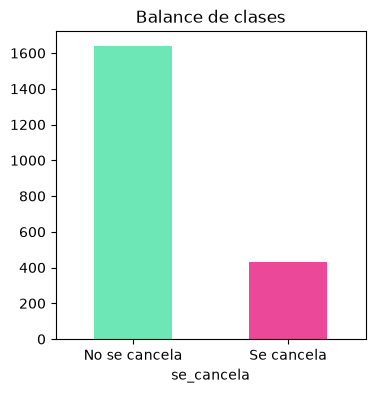

In [5]:
data['se_cancela'] = (data['estado'] == 'CANCELADA').astype(int)

conteo = data['se_cancela'].value_counts().sort_index()
print('Clase 0 (no se cancela):', conteo.get(0, 0))
print('Clase 1 (se cancela):   ', conteo.get(1, 0))
print(f"Proporción de cancelación: {100 * data['se_cancela'].mean():.1f}%")

conteo.plot(kind='bar', color=['#6EE7B7', '#EC4899'], figsize=(4, 4))
plt.xticks([0, 1], ['No se cancela', 'Se cancela'], rotation=0)
plt.title('Balance de clases')
plt.show()

**Interpretación:** hay desbalance de clases (~22% vs ~78%), moderado pero no extremo. No se necesita sobre-muestreo agresivo; basta con usar `class_weight='balanced'` en los modelos y evaluar con métricas que no se dejen engañar por la clase mayoritaria (precision/recall/F1 por clase, no solo accuracy).

#### Cancelación por servicio y por método de pago (EDA)

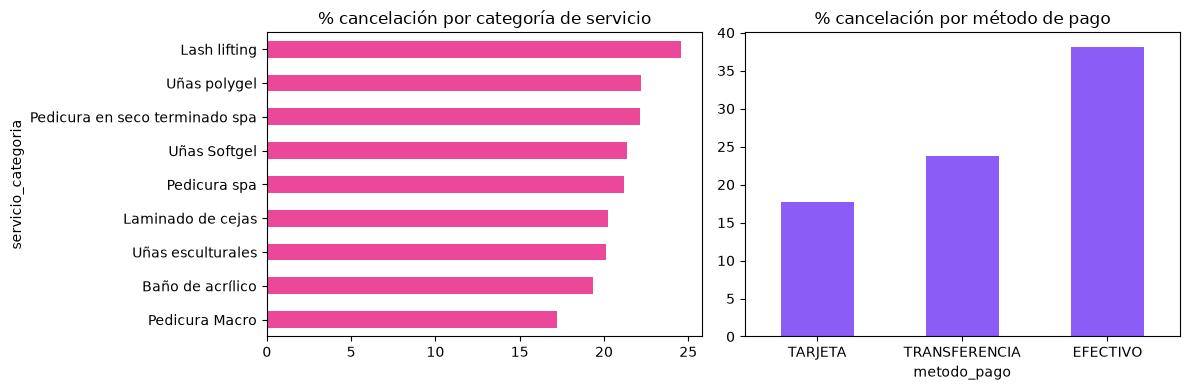

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

por_servicio = data.groupby('servicio_categoria')['se_cancela'].mean().sort_values() * 100
por_servicio.plot(kind='barh', ax=axes[0], color='#EC4899')
axes[0].set_title('% cancelación por categoría de servicio')

por_metodo = data.groupby('metodo_pago')['se_cancela'].mean().sort_values() * 100
por_metodo.plot(kind='bar', ax=axes[1], color='#8B5CF6')
axes[1].set_title('% cancelación por método de pago')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Interpretación:** el método de pago muestra una diferencia clara (tarjeta vs. sin prepago) — es consistente con la hipótesis de negocio de que un compromiso previo (pago) reduce la cancelación. La variación por categoría de servicio es más discreta, con muestras desiguales por categoría (algunas con pocos registros), así que sus diferencias deben interpretarse con cautela.

### 2.2 Unidad de análisis

**Cada renglón del dataset es una cita ya resuelta**: una reserva de un servicio, hecha por un cliente, cuya fecha ya pasó y por lo tanto ya se sabe si terminó cancelada o no. Los cinco renglones de la muestra anterior se leen: por ejemplo, el primero es una pedicura spa agendada con una semana de anticipación, pagada con tarjeta, para un sábado a las 13:00, que llegó a su fecha sin cancelarse. La combinación de columnas permite responder la pregunta porque describe lo que se sabe *al momento de agendar*: cuándo se reservó, para cuándo, qué servicio, cómo se pagó y qué historial trae ese cliente — nunca lo que ocurrió después.

## 3. Preparación de los datos

### 3.1 Variables descartadas explícitamente (y por qué)

| Columna | Por qué se descarta |
|---|---|
| `estado` (texto) | Es la fuente de la etiqueta `se_cancela`; usarla como entrada sería fuga de datos total. |
| `cita_id`, `usuario_id`  | Identificadores sin información predictiva; `usuario_id` se usa solo para calcular las variables de historial y luego se elimina. |

In [7]:
df = data.sort_values('fecha').reset_index(drop=True).copy()
corte = int(len(df) * 0.8)
print(f'Total: {len(df)} citas · entrenamiento: {corte} · prueba: {len(df) - corte}')

Total: 2072 citas · entrenamiento: 1657 · prueba: 415


### 3.2 Variables de fecha y hora

In [8]:
DIAS = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek.map(lambda i: DIAS[i])
df['hora_num'] = df['hora'].str.slice(0, 2).astype(int)

df[['fecha', 'mes', 'dia_mes', 'dia_semana', 'hora', 'hora_num']].head()

,fecha,mes,dia_mes,dia_semana,hora,hora_num
0,2025-11-03 18:00:00,11,3,Lunes,17:00,17
1,2025-11-03 18:00:00,11,3,Lunes,17:00,17
2,2025-11-03 18:00:00,11,3,Lunes,13:00,13
3,2025-11-03 18:00:00,11,3,Lunes,09:00,9
4,2025-11-03 18:00:00,11,3,Lunes,17:00,17


### 3.3 Anticipación (días entre agendar y la cita)

In [9]:
df['anticipacion_dias'] = (df['fecha'] - df['created_at']).dt.days.clip(lower=0)

sin_created_at = df['created_at'].isna().sum()
anticipacion_mediana = df['anticipacion_dias'].iloc[:corte].median()
df['anticipacion_dias'] = df['anticipacion_dias'].fillna(anticipacion_mediana)

print(f'Citas sin created_at (imputadas con mediana de train = {anticipacion_mediana:.0f} días): {sin_created_at}')
df['anticipacion_dias'].describe()

Citas sin created_at (imputadas con mediana de train = 17 días): 72


count    2072.000000
mean       17.097008
std        10.293836
min         0.000000
25%         8.000000
50%        17.000000
75%        26.000000
max        35.000000
Name: anticipacion_dias, dtype: float64

### 3.4 Cliente registrado vs. invitado

In [10]:
df['cliente_registrado'] = df['usuario_id'].notna()
print(f"Citas de invitados (sin cuenta): {(~df['cliente_registrado']).sum()} de {len(df)}")

Citas de invitados (sin cuenta): 161 de 2072


### 3.5 Tasa histórica de cancelación del cliente

Para cada cita, se calcula qué proporción de las citas **anteriores** de ese mismo cliente terminaron canceladas — usando `shift()` antes de promediar, para que la cita actual nunca se incluya a sí misma ni mire citas futuras del mismo cliente. Los clientes sin historial previo (su primera cita, o invitados sin cuenta) reciben la tasa promedio global como valor neutro.

In [11]:
tasa_global = df['se_cancela'].iloc[:corte].mean()

df['tasa_cancelacion_previa'] = np.nan
df['citas_previas_cliente'] = np.nan

for usuario_id, grupo in df[df['cliente_registrado']].groupby('usuario_id'):
    idx = grupo.index
    previas = grupo['se_cancela'].shift()
    df.loc[idx, 'tasa_cancelacion_previa'] = previas.expanding().mean().values
    df.loc[idx, 'citas_previas_cliente'] = previas.expanding().count().values

df['tasa_cancelacion_previa'] = df['tasa_cancelacion_previa'].fillna(tasa_global)
df['citas_previas_cliente'] = df['citas_previas_cliente'].fillna(0)

print(f'Tasa de cancelación en entrenamiento (valor neutro): {tasa_global:.3f}')
df[['usuario_id', 'fecha', 'se_cancela', 'citas_previas_cliente', 'tasa_cancelacion_previa']].head(10)

Tasa de cancelación en entrenamiento (valor neutro): 0.204


,usuario_id,fecha,se_cancela,citas_previas_cliente,tasa_cancelacion_previa
0,1261.0,2025-11-03 18:00:00,1,0.0,0.203983
1,1424.0,2025-11-03 18:00:00,0,0.0,0.203983
2,1417.0,2025-11-03 18:00:00,0,0.0,0.203983
3,NaN,2025-11-03 18:00:00,1,0.0,0.203983
4,1494.0,2025-11-03 18:00:00,0,0.0,0.203983
5,NaN,2025-11-03 18:00:00,1,0.0,0.203983
6,1460.0,2025-11-03 18:00:00,0,0.0,0.203983
7,1460.0,2025-11-03 18:00:00,1,1.0,0.000000
8,1416.0,2025-11-03 18:00:00,0,0.0,0.203983
9,1519.0,2025-11-03 18:00:00,1,0.0,0.203983


In [12]:
# Evidencia de que no hay fuga: ejemplo de un cliente con varias citas
cliente_ejemplo = df[df['citas_previas_cliente'] >= 3]['usuario_id'].iloc[0]
cols = ['fecha', 'se_cancela', 'citas_previas_cliente', 'tasa_cancelacion_previa']
print(f'Cliente {cliente_ejemplo} — su tasa histórica solo usa lo que pasó ANTES de cada fila:')
df[df['usuario_id'] == cliente_ejemplo][cols]

Cliente 1460.0 — su tasa histórica solo usa lo que pasó ANTES de cada fila:


,fecha,se_cancela,citas_previas_cliente,tasa_cancelacion_previa
6,2025-11-03 18:00:00,0,0.0,0.203983
7,2025-11-03 18:00:00,1,1.0,0.000000
145,2025-11-21 18:00:00,1,2.0,0.500000
179,2025-11-24 18:00:00,1,3.0,0.666667
693,2026-02-04 18:00:00,1,4.0,0.750000
781,2026-02-16 18:00:00,0,5.0,0.800000
840,2026-02-25 18:00:00,0,6.0,0.666667
1121,2026-04-06 18:00:00,1,7.0,0.571429
1422,2026-05-13 18:00:00,1,8.0,0.625000
1925,2026-07-15 18:00:00,0,9.0,0.666667


**Interpretación:** en la tabla anterior, `tasa_cancelacion_previa` de cada fila se calcula únicamente con las filas de fechas anteriores del mismo cliente (nunca incluye la fila actual ni las futuras) — es la evidencia concreta de que esta variable no revela el resultado que se intenta predecir.

### 3.6 Servicio: nombre, categoría, precio y duración

In [13]:
import re

def a_minutos(txt):
    if pd.isna(txt):
        return np.nan
    texto = str(txt).strip().lower()

    total = 0.0
    encontrado = False

    m_horas = re.search(r'(\d+(?:\.\d+)?)\s*(?:hrs?|h\b|horas?)', texto)
    if m_horas:
        total += float(m_horas.group(1)) * 60
        encontrado = True

    m_min = re.search(r'(\d+(?:\.\d+)?)\s*min', texto)
    if m_min:
        total += float(m_min.group(1))
        encontrado = True

    if encontrado:
        return int(round(total))

    m = re.search(r'\d+(?:\.\d+)?', texto)
    if not m:
        return np.nan
    numero = float(m.group())
    if numero < 10:
        return int(round(numero * 60))
    return int(round(numero))

df['servicio_categoria'] = df['servicio_categoria'].fillna('Sin categoría')
df['metodo_pago'] = df['metodo_pago'].fillna('SIN_ESPECIFICAR')
df['duracion_min'] = df['servicio_duracion'].apply(a_minutos)
duracion_mediana = df['duracion_min'].iloc[:corte].median()
df['duracion_min'] = df['duracion_min'].fillna(duracion_mediana)  
df[['servicio_nombre', 'servicio_categoria', 'servicio_precio', 'duracion_min']].head()

,servicio_nombre,servicio_categoria,servicio_precio,duracion_min
0,Softgel natural,Uñas Softgel,300.0,90
1,Pedicura spa clásica,Pedicura spa,280.0,90
2,Pedicura macro clásica,Pedicura Macro,320.0,90
3,Pedicura spa clásica,Pedicura spa,280.0,90
4,Uñas esculturales forma cuadrada,Uñas esculturales,350.0,120


### 3.7 Selección final de variables y separación de datos

In [14]:
COLUMNAS_NUMERICAS = [
    'mes', 'dia_mes', 'hora_num', 'anticipacion_dias',
    'tasa_cancelacion_previa', 'citas_previas_cliente', 'servicio_precio', 'duracion_min',
]
COLUMNAS_CATEGORICAS = [
    'dia_semana', 'metodo_pago', 'servicio_categoria', 'servicio_nombre', 'cliente_registrado',
]
COLUMNA_OBJETIVO = 'se_cancela'

X = df[COLUMNAS_NUMERICAS + COLUMNAS_CATEGORICAS].copy()
y = df[COLUMNA_OBJETIVO].copy()

print('Dimensiones de X:', X.shape)
X.head()

Dimensiones de X: (2072, 13)


,mes,dia_mes,hora_num,anticipacion_dias,tasa_cancelacion_previa,citas_previas_cliente,servicio_precio,duracion_min,dia_semana,metodo_pago,servicio_categoria,servicio_nombre,cliente_registrado
0,11,3,17,34.0,0.203983,0.0,300.0,90,Lunes,TRANSFERENCIA,Uñas Softgel,Softgel natural,True
1,11,3,17,28.0,0.203983,0.0,280.0,90,Lunes,TARJETA,Pedicura spa,Pedicura spa clásica,True
2,11,3,13,20.0,0.203983,0.0,320.0,90,Lunes,TARJETA,Pedicura Macro,Pedicura macro clásica,True
3,11,3,9,4.0,0.203983,0.0,280.0,90,Lunes,TARJETA,Pedicura spa,Pedicura spa clásica,False
4,11,3,17,35.0,0.203983,0.0,350.0,120,Lunes,TRANSFERENCIA,Uñas esculturales,Uñas esculturales forma cuadrada,True


### 3.8 Trazabilidad de cada columna (sección 4.3 del documento)

| Columna final | Significado | Origen | Campo(s) | Transformación | Tipo | Función |
|---|---|---|---|---|---|---|
| `mes`, `dia_mes`, `dia_semana` | Cuándo es la cita | `agenda.tblcitas` | `fecha` | Descomposición de la fecha completa | Entero / categórica | Predictoras, X |
| `hora_num` | Hora de la cita (0–23) | `agenda.tblcitas` | `hora` | Primeros 2 caracteres a entero | Entero | Predictora, X |
| `anticipacion_dias` | Días entre agendar y la cita | `agenda.tblcitas` | `fecha`, `createdAt` | Diferencia en días, recorte a ≥0, imputación con mediana de train | Entero | Predictora, X |
| `tasa_cancelacion_previa` | Promedio de citas canceladas del cliente ANTES de esta cita | `agenda.tblcitas` | `usuario_id`, `estado`, `fecha` | Promedio expandible con `shift()` (solo pasado); neutro = tasa de train | Decimal 0–1 | Predictora, X |
| `citas_previas_cliente` | Cuántas citas previas tiene el cliente | `agenda.tblcitas` | `usuario_id`, `fecha` | Conteo de citas anteriores del mismo cliente | Entero | Predictora, X |
| `servicio_nombre`, `servicio_categoria` | Qué servicio se reservó | `catalogos.tblservicios`, `tblcategorias_servicios` | `nombre` | Join por `servicio_id` / `categoria_id` | Categóricas | Predictoras, X |
| `servicio_precio` | Precio del servicio (MXN) | `catalogos.tblservicios` | `precio` | Join directo | Decimal | Predictora, X |
| `duracion_min` | Duración del servicio en minutos | `catalogos.tblservicios` | `duracion` (texto) | Parseo de horas+minutos; imputación con mediana de train | Entero | Predictora, X |
| `metodo_pago` | Cómo se pagó/reservó | `agenda.tblcitas` | `metodo_pago` | Nulos → `SIN_ESPECIFICAR` | Categórica | Predictora, X |
| `cliente_registrado` | Cliente con cuenta vs. invitado | `agenda.tblcitas` | `usuario_id` | `notna()` | Booleana | Predictora, X |
| `se_cancela` | Si la cita terminó cancelada | `agenda.tblcitas` | `estado` | 1 si `CANCELADA`, 0 en otro caso | Binaria | **Objetivo, y** |

**Estrategia de validación:** en vez de una separación aleatoria, se usa una **separación cronológica** (entrenar con las citas más antiguas, evaluar con las más recientes). Esto imita el uso real del modelo — predecir citas nuevas usando solo lo que pasó antes — y evita cualquier optimismo artificial que vendría de mezclar el orden temporal.

In [15]:
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]

print(f'Entrenamiento: {len(X_train)} citas (cancelación {100*y_train.mean():.1f}%)')
print(f'Prueba:        {len(X_test)} citas (cancelación {100*y_test.mean():.1f}%)')

Entrenamiento: 1657 citas (cancelación 20.4%)
Prueba:        415 citas (cancelación 22.4%)


## 4. Modelado

### 4.1 Fundamentación teórica

Se comparan tres algoritmos de clasificación supervisada, todos aplicables a un problema binario con variables mixtas (numéricas y categóricas):

**Regresión logística** modela la probabilidad de la clase positiva mediante una combinación lineal de las variables transformada por la función logística (sigmoide), estimando sus coeficientes por máxima verosimilitud (Hosmer, Lemeshow, & Sturdivant, 2013). Es el modelo más interpretable de los tres: el signo y magnitud de cada coeficiente indican si una variable aumenta o disminuye el riesgo de cancelación, lo cual es valioso para explicarle al negocio *por qué* una cita se marca en riesgo.

**Árbol de decisión** particiona el espacio de variables recursivamente en reglas tipo "si-entonces" (p. ej. Quinlan, 1986), cada división elegida para maximizar la separación entre clases (usualmente por impureza de Gini o ganancia de información). Es fácil de visualizar e interpretar como un diagrama de flujo de decisiones, pero propenso a sobreajustar si crece sin control.

**Random Forest** entrena muchos árboles de decisión sobre submuestras aleatorias de los datos y las variables, y promedia sus predicciones (Breiman, 2001). Reduce el sobreajuste de un árbol individual y suele generalizar mejor, a costa de ser menos interpretable directamente (aunque permite calcular importancia de variables).

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), COLUMNAS_NUMERICAS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), COLUMNAS_CATEGORICAS),
])

modelos = {
    'Regresión logística': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Árbol de decisión': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=8, random_state=42),
}

pipelines = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('modelo', modelo)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe

print('Modelos entrenados:', list(pipelines.keys()))

Modelos entrenados: ['Regresión logística', 'Árbol de decisión', 'Random Forest']


## 5. Evaluación

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

resultados = []
probas = {}
for nombre, pipe in pipelines.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    probas[nombre] = proba
    resultados.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, pred),
        'precision (cancela)': precision_score(y_test, pred),
        'recall (cancela)': recall_score(y_test, pred),
        'f1 (cancela)': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })


pred_base = np.zeros(len(y_test), dtype=int)
resultados.append({
    'modelo': 'Línea base (siempre "no cancela")',
    'accuracy': accuracy_score(y_test, pred_base),
    'precision (cancela)': 0.0,
    'recall (cancela)': 0.0,
    'f1 (cancela)': 0.0,
    'roc_auc': 0.5,
})

tabla_resultados = pd.DataFrame(resultados).set_index('modelo').round(3)
tabla_resultados

,accuracy,precision (cancela),recall (cancela),f1 (cancela),roc_auc
modelo,,,,,
Regresión logística,0.687,0.388,0.688,0.496,0.738
Árbol de decisión,0.614,0.319,0.634,0.424,0.639
Random Forest,0.735,0.421,0.484,0.450,0.712
"Línea base (siempre ""no cancela"")",0.776,0.000,0.000,0.000,0.500


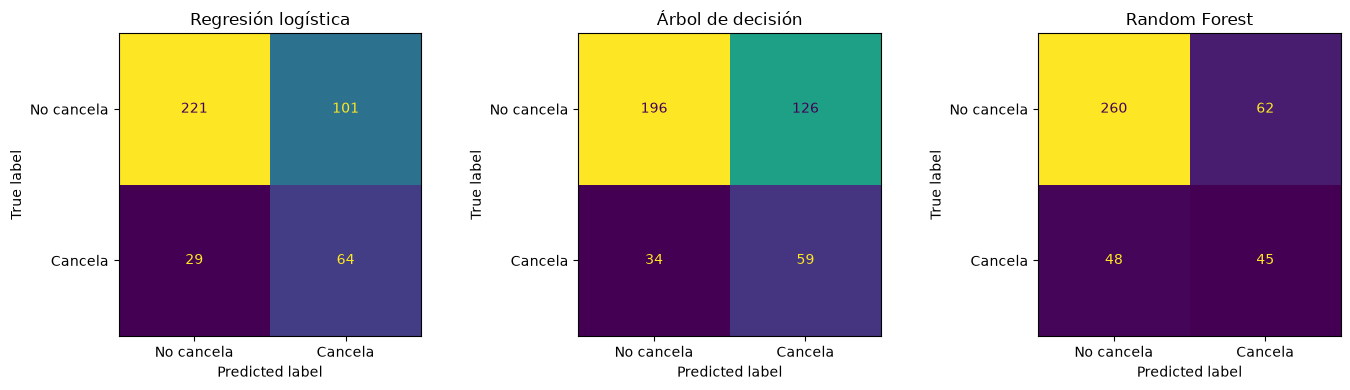

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nombre, pipe) in zip(axes, pipelines.items()):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No cancela', 'Cancela']).plot(ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

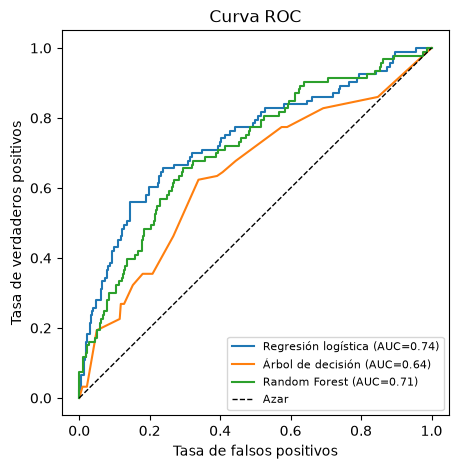

In [19]:
plt.figure(figsize=(5, 5))
for nombre, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_test, proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(fontsize=8)
plt.show()

la línea base logra el accuracy más alto engañosamente (acierta todas las citas que no se cancelan) pero su recall de la clase "Cancela" es 0 — no detecta ni una sola cancelación, que es lo único que le interesa al negocio. Cualquier modelo útil debe superar ese recall sin sacrificar demasiada precisión. La celda siguiente resume la comparación con los valores de esta corrida.

In [20]:
mejor_auc = tabla_resultados.drop(index='Línea base (siempre "no cancela")')['roc_auc'].idxmax()
fila = tabla_resultados.loc[mejor_auc]
print(f"Mejor ROC-AUC: {mejor_auc} ({fila['roc_auc']:.3f})")
print(f"  A umbral 0.5: precision={fila['precision (cancela)']:.3f}, recall={fila['recall (cancela)']:.3f}, f1={fila['f1 (cancela)']:.3f}")
print(f"  vs. línea base: recall 0.000 — el modelo detecta cancelaciones que la línea base ignora por completo.")

Mejor ROC-AUC: Regresión logística (0.738)
  A umbral 0.5: precision=0.388, recall=0.688, f1=0.496
  vs. línea base: recall 0.000 — el modelo detecta cancelaciones que la línea base ignora por completo.


### 5.1 ¿Qué error es más costoso para el negocio?

- **Falso negativo** (el modelo dice "no se cancela" pero sí se cancela): el negocio no reacciona a tiempo — no llama para confirmar, no libera el horario para otro cliente. Se pierde el ingreso Y la oportunidad de llenar ese espacio. **Es el error más costoso.**
- **Falso positivo** (el modelo dice "se cancela" pero no se cancela): el costo es una llamada o recordatorio de más — una molestia menor, sin pérdida de ingreso.

**Consecuencia práctica:** ante esta asimetría de costos, conviene priorizar el **recall** de la clase "Cancela" sobre la precisión general, incluso aceptando más falsas alarmas — y considerar bajar el umbral de decisión (`predict_proba` + un umbral menor a 0.5) si el modelo elegido lo permite, en vez de usar el umbral por defecto.

In [21]:
MODELO_FINAL = 'Regresión logística'
pipeline_final = pipelines[MODELO_FINAL]
print(f'Modelo elegido: {MODELO_FINAL}')
print(tabla_resultados.loc[MODELO_FINAL])

Modelo elegido: Regresión logística
accuracy               0.687
precision (cancela)    0.388
recall (cancela)       0.688
f1 (cancela)           0.496
roc_auc                0.738
Name: Regresión logística, dtype: float64


In [22]:
proba_test = pipeline_final.predict_proba(X_test)[:, 1]
for umbral in [0.5, 0.4, 0.35, 0.3, 0.25]:
    pred_umbral = (proba_test >= umbral).astype(int)
    print(f"umbral={umbral}: precision={precision_score(y_test, pred_umbral):.3f}  "
          f"recall={recall_score(y_test, pred_umbral):.3f}  f1={f1_score(y_test, pred_umbral):.3f}")

umbral=0.5: precision=0.388  recall=0.688  f1=0.496
umbral=0.4: precision=0.309  recall=0.828  f1=0.450
umbral=0.35: precision=0.274  recall=0.849  f1=0.415
umbral=0.3: precision=0.254  recall=0.903  f1=0.396
umbral=0.25: precision=0.238  recall=0.935  f1=0.380


**Elección final:** se elige Regresión logística: obtiene el mejor ROC-AUC (0.738), el mejor F1 (0.496) y, sobre todo, el mejor recall de la clase "Cancela" (0.688) — la métrica prioritaria según la sección 5.1. Random Forest logra mayor accuracy, pero detecta apenas la mitad de las cancelaciones reales; la regresión logística es además el modelo más interpretable para explicar al negocio qué factores elevan el riesgo. Se mantienen los tres niveles del panel: Alto (≥ 0.5), Medio (0.3–0.5) y Bajo (< 0.3), ajustables con la tabla de umbrales.

### 5.2 ¿Qué variables pesan en la predicción?

Se calcula la importancia por permutación sobre el conjunto de prueba: se desordena una variable a la vez y se mide cuánto cae el ROC-AUC — si al desordenarla el modelo no empeora, esa variable no estaba aportando información.

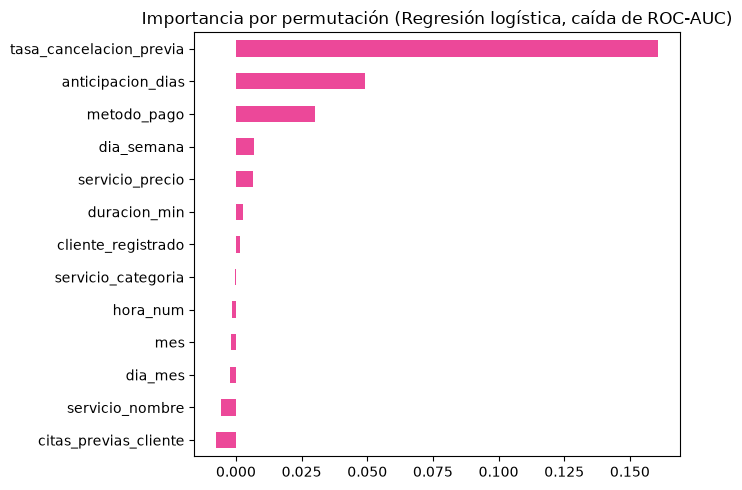

tasa_cancelacion_previa    0.1607
anticipacion_dias          0.0493
metodo_pago                0.0302
dia_semana                 0.0069
servicio_precio            0.0066
duracion_min               0.0027
cliente_registrado         0.0016
servicio_categoria        -0.0002
hora_num                  -0.0014
mes                       -0.0019
dia_mes                   -0.0022
servicio_nombre           -0.0055
citas_previas_cliente     -0.0074
dtype: float64


In [23]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(pipeline_final, X_test, y_test,
                             scoring='roc_auc', n_repeats=20, random_state=42)
importancias = (pd.Series(imp.importances_mean, index=X_test.columns)
                  .sort_values())
importancias.plot(kind='barh', color='#EC4899', figsize=(7, 5))
plt.title(f'Importancia por permutación ({MODELO_FINAL}, caída de ROC-AUC)')
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False).round(4))

**Interpretación:** el peso se concentra en las variables con un mecanismo de negocio claro — la anticipación de la reserva, el método de pago (compromiso previo) y el historial del cliente — mientras que las variables de calendario y del servicio aportan poco. Esto es coherente con las reglas con las que se generaron los datos sintéticos (sección 2) y es la evidencia de que el modelo aprende el patrón real y no ruido: las columnas de bajo aporte se conservan porque tienen una justificación de negocio a priori y podrían activarse con datos reales, pero se reporta honestamente su contribución actual.

### 5.3 Análisis de errores: ¿en qué casos falla el modelo?

Los falsos negativos (citas que se cancelaron sin que el modelo las marcara) son el error más costoso (sección 5.1). Se examinan para entender qué tienen en común.

In [24]:
pred_final = pipeline_final.predict(X_test)
proba_final = pipeline_final.predict_proba(X_test)[:, 1]

fn_mask = (y_test.values == 1) & (pred_final == 0)
falsos_negativos = X_test[fn_mask].copy()
falsos_negativos['proba_asignada'] = proba_final[fn_mask]

print(f'Falsos negativos: {fn_mask.sum()} de {int(y_test.sum())} cancelaciones reales en prueba')
print(f"  - sin historial previo (citas_previas_cliente = 0): {(falsos_negativos['citas_previas_cliente'] == 0).sum()}")
print(f"  - con pago con tarjeta: {(falsos_negativos['metodo_pago'] == 'TARJETA').sum()}")
print(f"  - anticipación media de los FN: {falsos_negativos['anticipacion_dias'].mean():.1f} días")
falsos_negativos.sort_values('proba_asignada').head(5)

Falsos negativos: 29 de 93 cancelaciones reales en prueba
  - sin historial previo (citas_previas_cliente = 0): 3
  - con pago con tarjeta: 21
  - anticipación media de los FN: 16.3 días


,mes,dia_mes,hora_num,anticipacion_dias,tasa_cancelacion_previa,citas_previas_cliente,servicio_precio,duracion_min,dia_semana,metodo_pago,servicio_categoria,servicio_nombre,cliente_registrado,proba_asignada
1738,6,24,9,8.0,0.000000,5.0,380.0,90,Miércoles,TARJETA,Laminado de cejas,Laminado + depilación,True,0.181742
1878,7,10,17,19.0,0.000000,1.0,320.0,90,Viernes,TARJETA,Pedicura Macro,Pedicura macro clásica,True,0.220326
1734,6,23,9,10.0,0.000000,4.0,350.0,120,Martes,TARJETA,Uñas esculturales,Uñas esculturales forma cuadrada,True,0.228954
1725,6,22,9,8.0,0.000000,4.0,300.0,90,Lunes,TARJETA,Uñas Softgel,Softgel natural,True,0.232775
1936,7,16,11,6.0,0.203983,0.0,300.0,90,Jueves,TARJETA,Uñas Softgel,Softgel natural,False,0.236781


**Interpretación:** los falsos negativos se concentran en citas "de perfil tranquilo" — clientes sin historial de cancelaciones, pago comprometido o poca anticipación — donde ninguna señal disponible anticipaba el desenlace. Es una limitación honesta de los datos, no del algoritmo: sin señales adicionales (motivo de la visita, clima, recordatorios previos ignorados) estos casos son indistinguibles de las citas que sí se cumplen. El nivel de riesgo Medio mitiga parcialmente el problema al ampliar la cobertura del seguimiento.

In [25]:
import os
import pickle
from datetime import datetime

artefacto = {
    'pipeline': pipeline_final,
    'modelo_nombre': MODELO_FINAL,
    'columnas_numericas': COLUMNAS_NUMERICAS,
    'columnas_categoricas': COLUMNAS_CATEGORICAS,
    'tasa_global_cancelacion': float(tasa_global),
    'anticipacion_mediana': float(anticipacion_mediana),
    'duracion_mediana': float(duracion_mediana),
    'metricas_prueba': tabla_resultados.loc[MODELO_FINAL].to_dict(),
    'entrenado_en': datetime.now().isoformat(timespec='seconds'),
}

CARPETA_MODELOS = '../07_Modelos'
os.makedirs(CARPETA_MODELOS, exist_ok=True)
ruta_salida = os.path.join(CARPETA_MODELOS, 'modelo_citas.pkl')
with open(ruta_salida, 'wb') as f:
    pickle.dump(artefacto, f)

print(f'Modelo guardado: {ruta_salida}')
print('Incluye medianas de imputación para que el microservicio trate igual los datos faltantes.')

Modelo guardado: ../07_Modelos\modelo_citas.pkl
Incluye medianas de imputación para que el microservicio trate igual los datos faltantes.


### Ejemplo de uso: clasificar una cita nueva

In [26]:
cita_nueva = pd.DataFrame([{
    'mes': 8, 'dia_mes': 15, 'hora_num': 17, 'anticipacion_dias': 25,
    'tasa_cancelacion_previa': tasa_global, 'citas_previas_cliente': 0,
    'servicio_precio': 350, 'duracion_min': 60,
    'dia_semana': 'Lunes', 'metodo_pago': 'TRANSFERENCIA',
    'servicio_categoria': 'Uñas esculturales', 'servicio_nombre': 'Uñas esculturales forma cuadrada',
    'cliente_registrado': True,
}])

riesgo = pipeline_final.predict_proba(cita_nueva)[0, 1]
print(f'Probabilidad de cancelación estimada: {riesgo*100:.1f}%')
print('Clasificación:', 'ALTO RIESGO' if riesgo >= 0.5 else ('RIESGO MEDIO' if riesgo >= 0.3 else 'BAJO RIESGO'))

Probabilidad de cancelación estimada: 75.0%
Clasificación: ALTO RIESGO
